In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

scoring = pd.read_csv("../data_processed/scoring_with_arrangement.csv", na_values=["NA"])
obligor = pd.read_csv("../data_raw/dat_obligor.csv", na_values=["NA"])

print(scoring.shape)
print(obligor.shape)

(36000, 10)
(31592, 4)


In [4]:
scoring_with_obligor = pd.merge(
    scoring,
    obligor[["YEAR", "IP_ID", "AGE", "EDUCATION"]],
    on=["YEAR", "IP_ID"],
    how="left"
)

print(scoring_with_obligor.shape)
print(scoring_with_obligor.shape[0] == scoring.shape[0])
print(scoring_with_obligor["AGE"].dtype)
print(scoring_with_obligor["EDUCATION"].dtype)
print("Missing AGE after merge:", scoring_with_obligor["AGE"].isna().sum())
print("Missing EDUCATION after merge:",scoring_with_obligor["EDUCATION"].isna().sum())
scoring_with_obligor.head()


(36000, 12)
True
float64
float64
Missing AGE after merge: 4271
Missing EDUCATION after merge: 4424


,YEAR,IP_ID,AR_ID,PD,PD_POOL,DFLT_FLAG,DEBT_RATIO,DPD,M_LAST_DPD,non_null_count,AGE,EDUCATION
0,2022,CFG053,2795120,9.925260e-01,5.0,1,1.000000,1.0,6.0,6.0,70.0,2.0
1,2022,NNA451,10210477,2.656939e-05,1.0,0,0.804767,NaN,NaN,4.0,72.0,2.0
2,2022,VLZ931,24787848,3.514735e-06,1.0,0,0.136493,NaN,NaN,4.0,44.0,2.0
3,2022,VVF064,35869938,5.868028e-06,1.0,0,0.522421,NaN,NaN,4.0,63.0,1.0
4,2022,DXH176,71765042,8.378070e-07,1.0,0,0.295783,NaN,NaN,4.0,20.0,1.0


<Figure size 600x400 with 0 Axes>

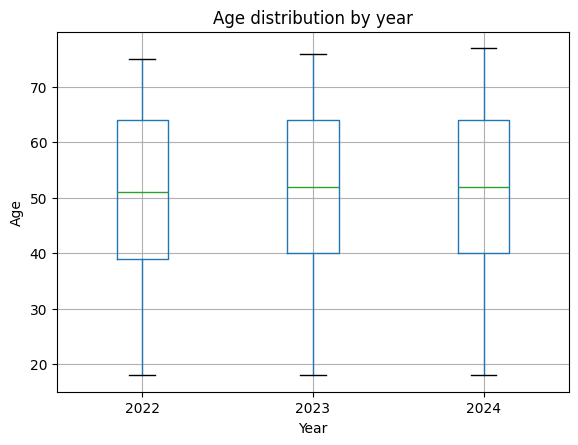

In [5]:
# This chart shows the age distribution of obligors by year.
# The median age and overall spread are stable over time, indicating a consistent customer profile.

plt.figure(figsize=(6, 4))
scoring_with_obligor.boxplot(column='AGE', by='YEAR')
plt.title('Age distribution by year')
plt.suptitle('')
plt.xlabel('Year')
plt.ylabel('Age')
plt.show()

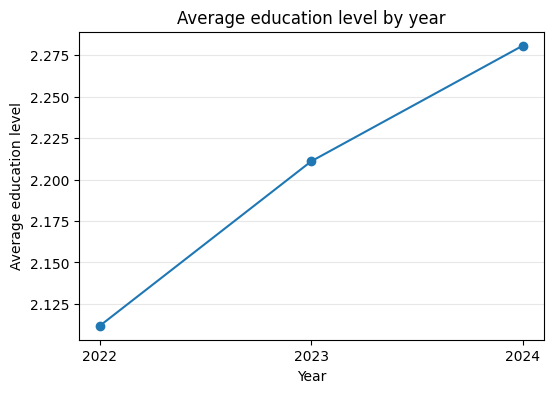

YEAR
2022    2.111800
2023    2.211072
2024    2.280813
Name: EDUCATION, dtype: float64

In [6]:
# The average education level slightly increases over time.
# This suggests a gradual change in portfolio composition towards more educated customers.

education_by_year = (scoring_with_obligor.groupby("YEAR")["EDUCATION"].mean())
plt.figure(figsize=(6, 4))
plt.plot(education_by_year.index, education_by_year.values, marker="o")
plt.title("Average education level by year")
plt.xlabel("Year")
plt.ylabel("Average education level")
plt.xticks(education_by_year.index)
plt.grid(axis="y", alpha=0.3)
plt.show()

education_by_year

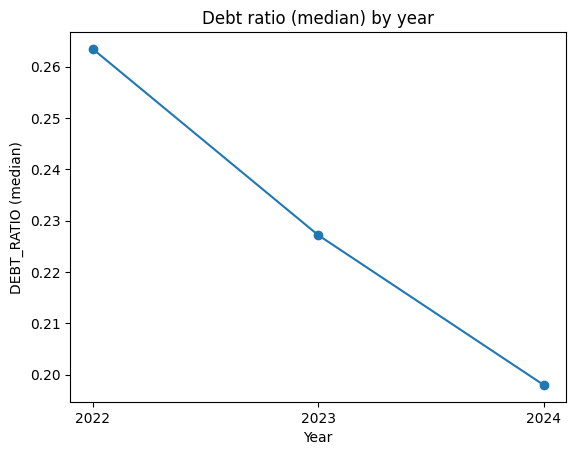

YEAR
2022    0.263450
2023    0.227174
2024    0.197975
Name: DEBT_RATIO, dtype: float64

In [7]:
# The median debt ratio changes slightly across years.
# No large jumps are observed, so overall debt levels look stable.

debt_median = scoring.groupby('YEAR')['DEBT_RATIO'].median()

plt.figure()
plt.plot(debt_median.index, debt_median.values, marker='o')
plt.title('Debt ratio (median) by year')
plt.xlabel('Year')
plt.ylabel('DEBT_RATIO (median)')
plt.xticks(debt_median.index)
plt.show()

debt_median

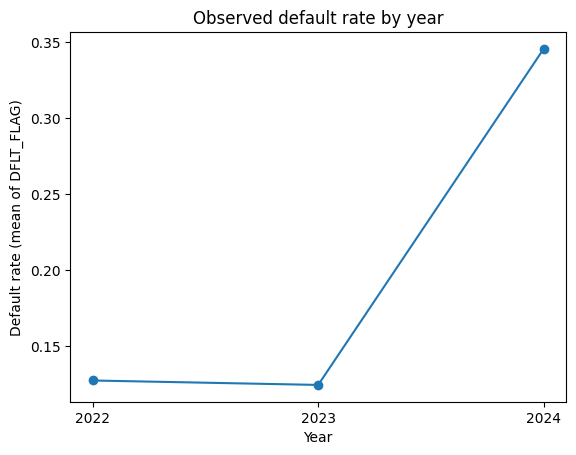

YEAR
2022    0.127333
2023    0.124417
2024    0.345750
Name: DFLT_FLAG, dtype: float64

In [8]:
# The observed default rate is stable in 2022–2023 and increases in 2024.
# This may indicate higher overall portfolio risk in the latest year.

default_rate_by_year = scoring.groupby('YEAR')['DFLT_FLAG'].mean()

plt.figure()
plt.plot(default_rate_by_year.index, default_rate_by_year.values, marker='o')
plt.title('Observed default rate by year')
plt.xlabel('Year')
plt.ylabel('Default rate (mean of DFLT_FLAG)')
plt.xticks(default_rate_by_year.index)
plt.show()

default_rate_by_year

<Figure size 640x480 with 0 Axes>

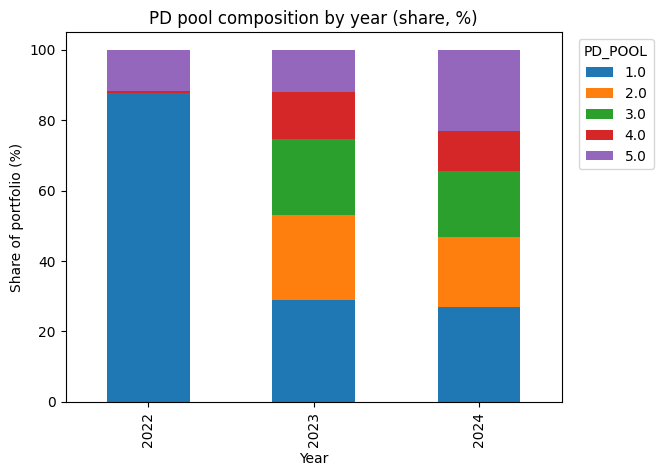

PD_POOL,1.0,2.0,3.0,4.0,5.0
YEAR,,,,,
2022,87.60,0.06,0.09,0.51,11.74
2023,28.95,24.07,21.67,13.16,12.15
2024,26.82,20.09,18.63,11.47,22.99


In [9]:
# This chart shows how the portfolio is distributed across PD pools over time.
# The share of higher risk pools increases in 2024, which is consistent with higher observed default rates.

pool_counts = scoring.groupby(['YEAR', 'PD_POOL'])['AR_ID'].count().unstack(fill_value=0)
pool_share = pool_counts.div(pool_counts.sum(axis=1), axis=0) * 100

plt.figure()
pool_share.plot(kind='bar', stacked=True)
plt.title('PD pool composition by year (share, %)')
plt.xlabel('Year')
plt.ylabel('Share of portfolio (%)')
plt.legend(title='PD_POOL', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

pool_share.round(2)

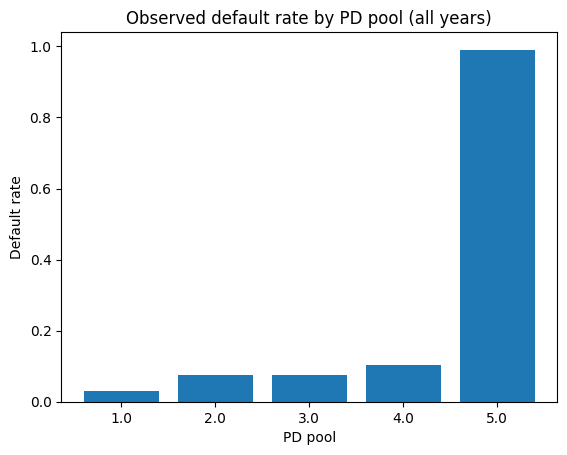

,PD_POOL,n,default_rate
0,1.0,16784,0.031220
1,2.0,5172,0.074633
2,3.0,4724,0.074090
3,4.0,2940,0.103741
4,5.0,5485,0.990702


In [13]:
# Default rates increase with higher PD pools.
# This indicates that PD pools correctly separate customers by risk level.

pd_available = scoring[scoring['PD'].notna()].copy()

default_by_pool = pd_available.groupby('PD_POOL')['DFLT_FLAG'].mean()
n_by_pool = pd_available.groupby('PD_POOL')['AR_ID'].count()

plt.figure()
plt.bar(default_by_pool.index.astype(str), default_by_pool.values)
plt.title('Observed default rate by PD pool (all years)')
plt.xlabel('PD pool')
plt.ylabel('Default rate')
plt.show()
pd.DataFrame({'n': n_by_pool, 'default_rate': default_by_pool}).reset_index()

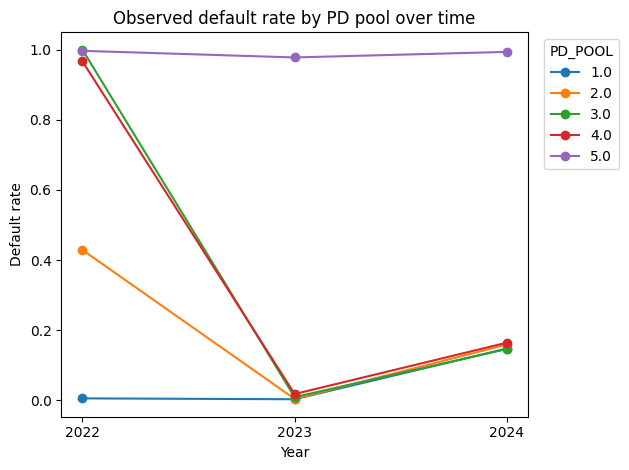

PD_POOL,1.0,2.0,3.0,4.0,5.0
YEAR,,,,,
2022,0.005165,0.428571,1.000000,0.966667,0.997091
2023,0.002658,0.003551,0.008679,0.017544,0.978184
2024,0.147321,0.158791,0.145939,0.164057,0.994050


In [14]:
# The highest risk pool (PD pool 5) is stable across years.
# Lower PD pools show different patterns over time, with less separation in 2023 ant 2024.

default_by_year_pool = pd_available.groupby(['YEAR', 'PD_POOL'])['DFLT_FLAG'].mean().unstack()

plt.figure()
for pool in default_by_year_pool.columns:
    plt.plot(default_by_year_pool.index, default_by_year_pool[pool], marker='o', label=str(pool))

plt.title('Observed default rate by PD pool over time')
plt.xlabel('Year')
plt.ylabel('Default rate')
plt.xticks(default_by_year_pool.index)
plt.legend(title='PD_POOL', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

default_by_year_pool